In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import nltk
import pymorphy3


![pipeline.png](pipeline.png)

# Обработка текста  

In [4]:
train_df = pd.read_json("train.jsonl", lines=True)
val_df = pd.read_json("validation.jsonl", lines=True)
test_df = pd.read_json("test.jsonl", lines=True)

In [5]:
print(train_df.head())

   id                                               text  label label_text
0   0  Если честно, меня не очень впечатлила новость,...      2       Good
1   1  Сразу скажу — книгу я не читала, поэтому о том...      0        Bad
2   2  Общее впечатление таково: фильм не назовешь пл...      1    Neutral
3   3  Только что посмотрела этот «фильм». Рецензии п...      0        Bad
4   4  Скажу сразу же, фильм — гениален! Если есть те...      2       Good


In [6]:
print(train_df['label_text'].value_counts())


label_text
Good       3500
Bad        3500
Neutral    3500
Name: count, dtype: int64


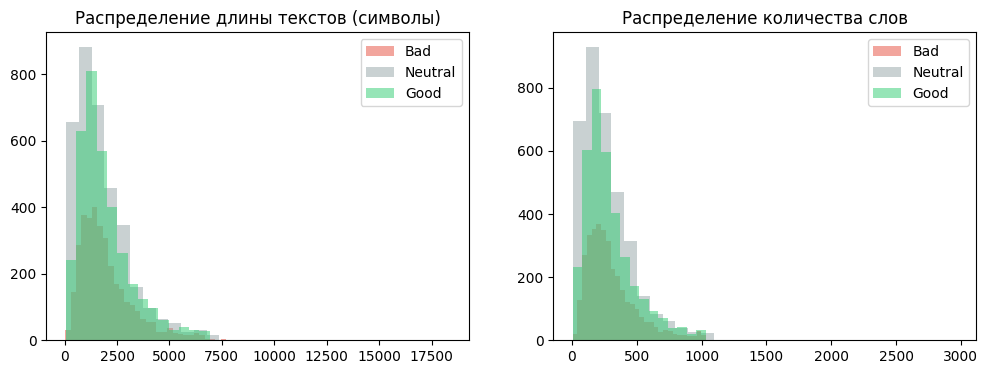

In [7]:
train_df["text_len"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label_text, color in [("Bad", "#e74c3c"), ("Neutral", "#95a5a6"), ("Good", "#2ecc71")]:
    subset = train_df[train_df["label_text"] == label_text]
    axes[0].hist(subset["text_len"], bins=30, alpha=0.5, label=label_text, color=color)
    axes[1].hist(subset["word_count"], bins=30, alpha=0.5, label=label_text, color=color)
axes[0].set_title("Распределение длины текстов (символы)")
axes[0].legend()
axes[1].set_title("Распределение количества слов")
axes[1].legend()

In [8]:
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords


In [9]:
from nltk import word_tokenize
import re
morph = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words("russian"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text ) #знаки 
    text = re.sub(r"http\S+|www\.\S+", " ", text) #ссылки
    text = re.sub(r"\S+@\S+", " ", text) #email
    text = re.sub(r"[^а-яёa-z\s]", " ", text) #всё кроме букв
    text = re.sub(r"\s+", " ", text)
    tokens = word_tokenize(text, language='russian')
    tokens = [
        morph.parse(token)[0].normal_form
        for token in tokens
        if token not in russian_stopwords and len(token) > 2
    ]
    return " ".join(tokens)


# NLP векторизация 

# TF-IDF


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
tfidf = TfidfVectorizer(
    max_features=20000, #количество признаков
    ngram_range=(1, 2), #1-граммы и 2-граммы
    min_df=3, #отбрасывает n-граммы, которые встречаются в меньше 3-х документов
    max_df=0.95, #отбрасывает n-граммы, которые встречаются в более чем 95% документов
)
# чтобы не делать ячейку с препроцессингом для каждого датасета tfidf = TfidfVectorizer(preprocessor=preprocess_text)

In [13]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
val_df["clean_text"] = val_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [ ]:


y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

In [15]:
X_train_tf = tfidf.fit_transform(train_df["clean_text"])
X_val_tf = tfidf.transform(val_df["clean_text"])
X_test_tf = tfidf.transform(test_df["clean_text"])



print(f"Размер словаря:       {len(tfidf.vocabulary_)}")
print(f"Размер матрицы train: {X_train_tf.shape}")
print(f"Размер матрицы val:   {X_val_tf.shape}")
print(f"Размер матрицы test:  {X_test_tf.shape}")
print(f"Размер матрицы test:  {y_test[:10]}")

Размер словаря:       20000
Размер матрицы train: (10500, 20000)
Размер матрицы val:   (1500, 20000)
Размер матрицы test:  (1500, 20000)
Размер матрицы test:  [1 0 0 1 0 0 2 2 1 2]


In [16]:
tfidf.get_feature_names_out()[:10] #возвращает первые 10 слов/n-грамм из словаря TF-IDF (отсортированных по алфавиту)

array(['all', 'alone', 'alone the', 'and', 'are', 'asylum', 'black',
       'bloodrayne', 'club', 'comedy'], dtype=object)

# Word2Vec

In [17]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from gensim.models import Word2Vec

In [19]:
train_sentences = train_df["clean_text"].apply(str.split).tolist()
val_sentences = val_df["clean_text"].apply(str.split).tolist()
test_sentences = test_df["clean_text"].apply(str.split).tolist()

In [20]:
word2vec = Word2Vec(
    sentences=train_sentences, 
    min_count=10,
    vector_size=300,
    window=5,
    negative=10,
    alpha=0.03,
    min_alpha=0.0007,
    sample=6e-5,
    sg=1,
)
#sg = 0 = CBOW, sg =1 = Skipgram
#vector_size =  размер вектора
# min_count = минимальная частота слов дляв ключения в словарь
# alpha|min_alpha-начальная и конечная скорость обучения 
# negative -  число негтивных сэмплов
#  hs - иеархаический softmax
word2vec.save('word2vec')

In [21]:
word2vec.train(val_sentences, total_examples=word2vec.corpus_count, epochs=30, report_delay=1)

(4512424, 8279940)

In [35]:
word2vec.wv.most_similar(positive=["интересно"])

[('любопытно', 0.5631027221679688),
 ('внимательно', 0.5282484292984009),
 ('захватывающий', 0.5006856918334961),
 ('невнимательно', 0.48860543966293335),
 ('неприятно', 0.48629629611968994),
 ('скучно', 0.4613487124443054),
 ('вдумчиво', 0.44516563415527344),
 ('интересный', 0.44490885734558105),
 ('забавно', 0.44399383664131165),
 ('приятно', 0.44179287552833557)]

In [36]:
word2vec.wv.most_similar(positive=["мужчина"])

[('женщина', 0.6630555391311646),
 ('инфальтильный', 0.5628509521484375),
 ('зазорно', 0.5061599016189575),
 ('мальчишка', 0.4652043282985687),
 ('доходяга', 0.4579786956310272),
 ('любящий', 0.4564777612686157),
 ('мужик', 0.4563278555870056),
 ('слабак', 0.4509527385234833),
 ('сознать', 0.4384579360485077),
 ('девчонка', 0.4329433739185333)]

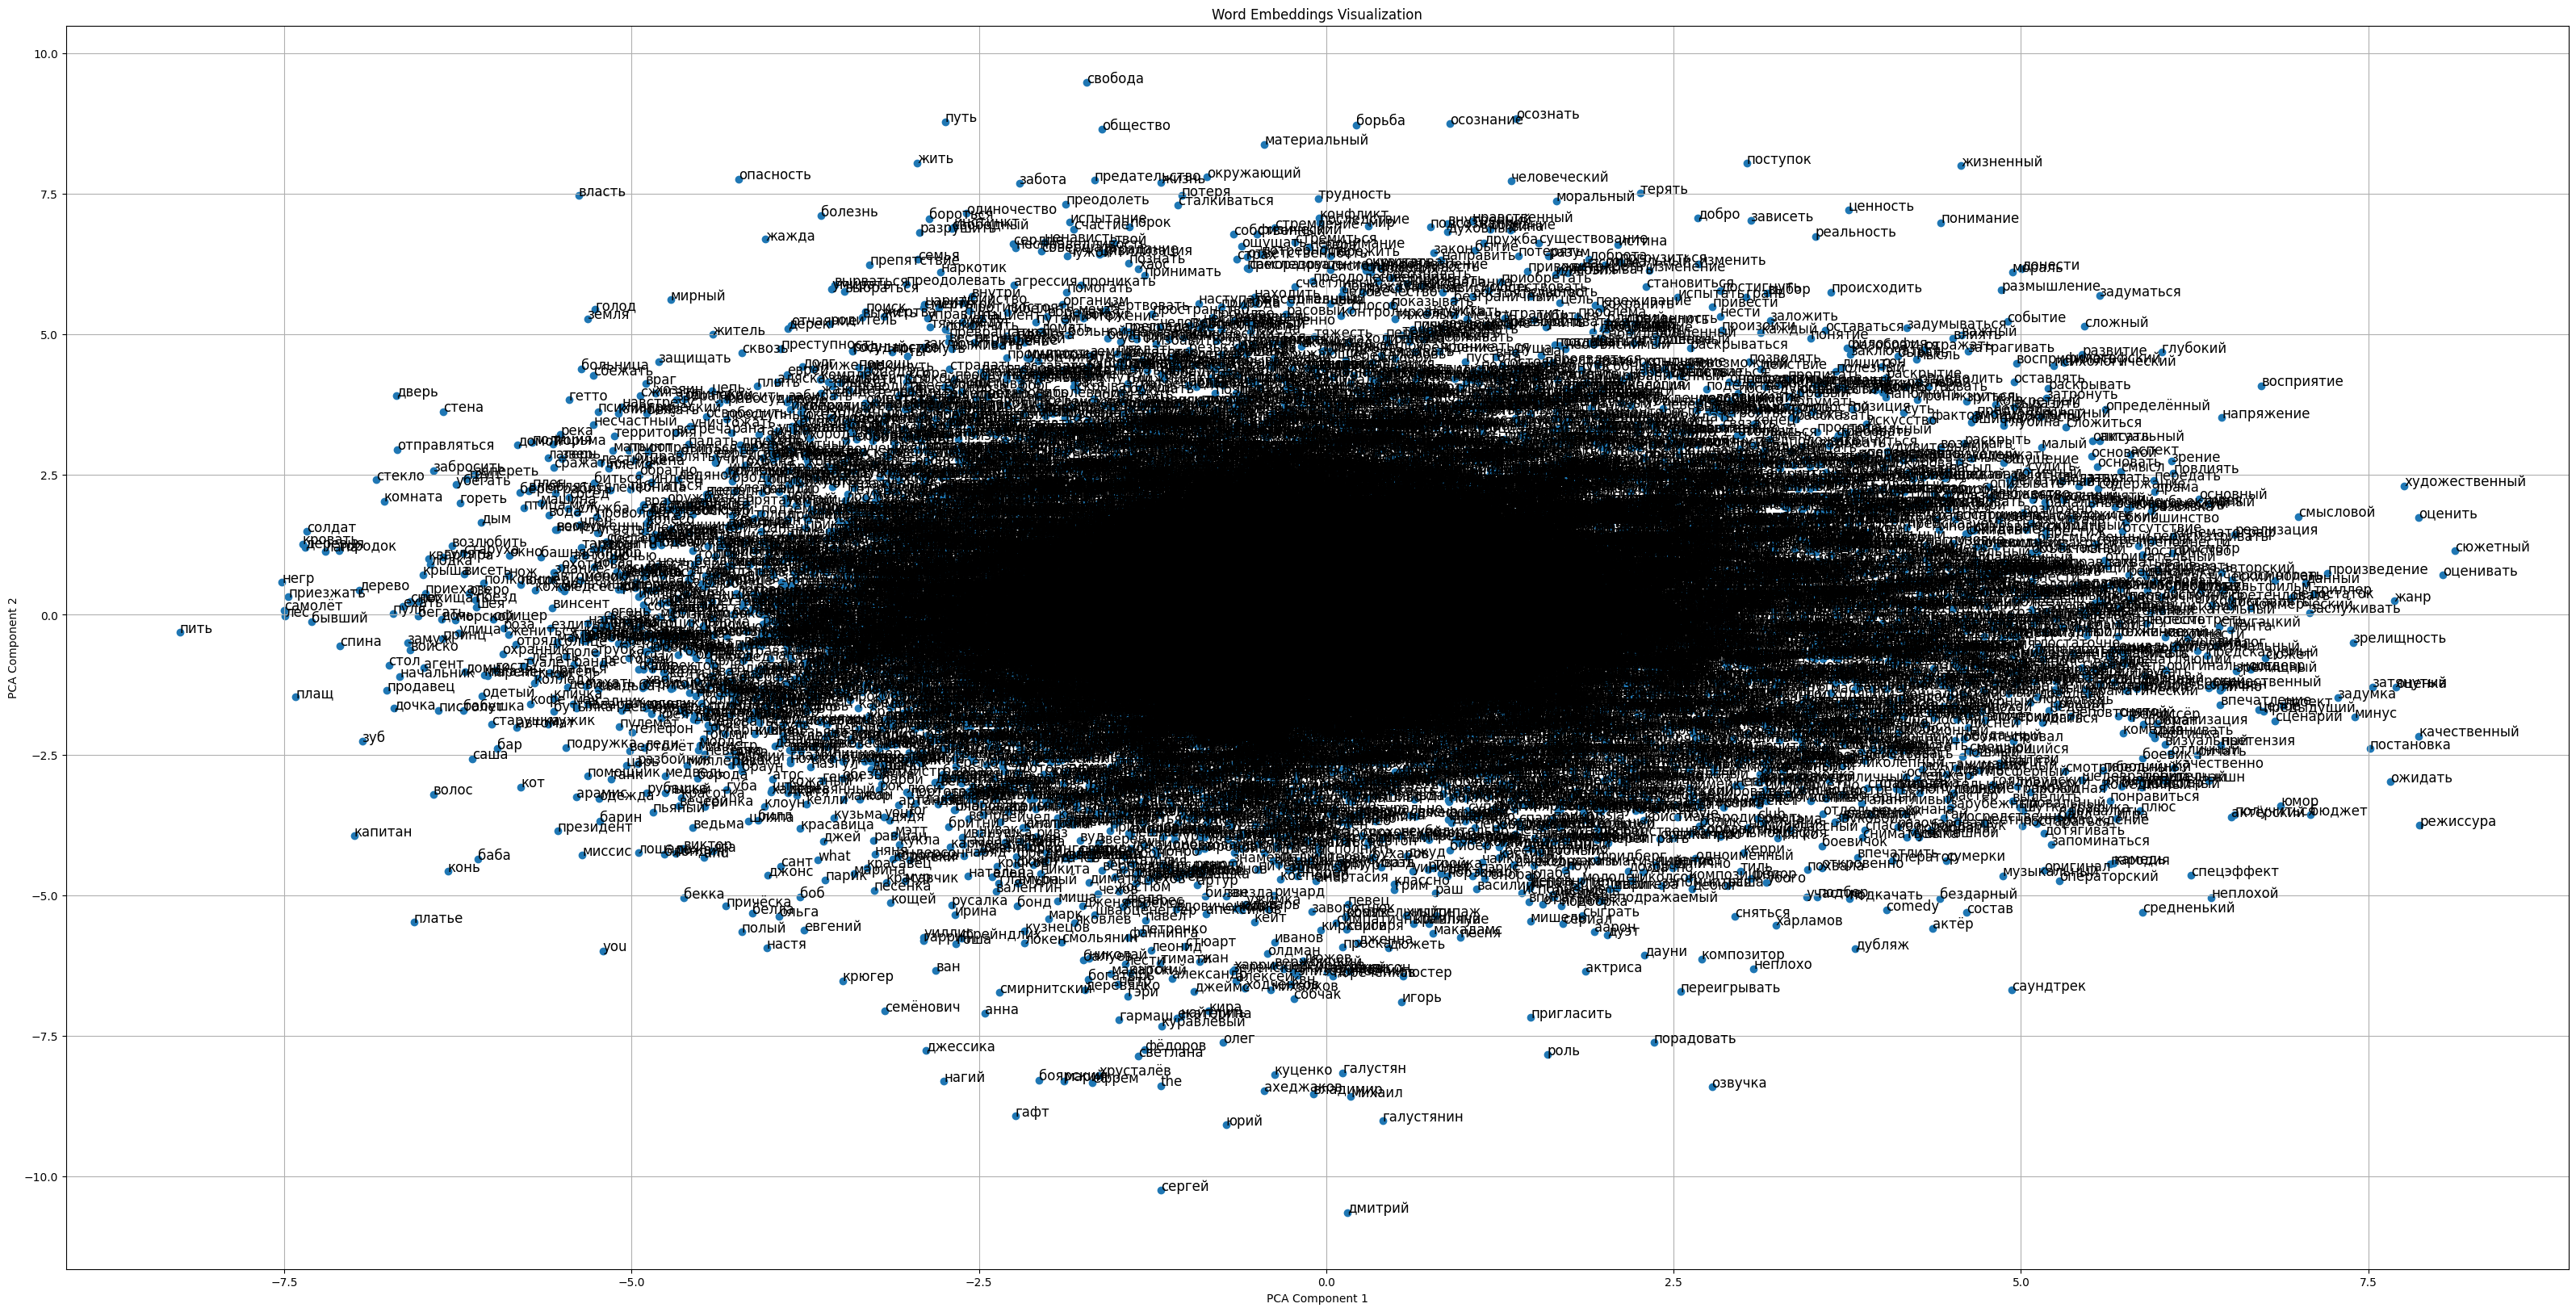

In [38]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
# Reduce dimensionality of word vectors for visualization
word_vectors = word2vec.wv[word2vec.wv.index_to_key]  # Get the word vectors
pca = PCA(n_components=2)  # Initialize PCA
result = pca.fit_transform(word_vectors)  # Fit and transform the word vectors

# Plot the words in a 2D space
plt.figure(figsize=(40, 20))
plt.scatter(result[:, 0], result[:, 1])

# Annotate words in the plot
words = list(word2vec.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

In [22]:

def text_to_vec(tokens, model, size=300):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(size)

X_train_w2v = np.array([text_to_vec(s, word2vec, 200) for s in train_sentences])
X_val_w2v   = np.array([text_to_vec(s, word2vec, 200) for s in val_sentences])
X_test_w2v  = np.array([text_to_vec(s, word2vec, 200) for s in test_sentences])

print(f"X_train_w2v: {X_train_w2v.shape}")
print(f"X_val_w2v:   {X_val_w2v.shape}")
print(f"X_test_w2v:  {X_test_w2v.shape}")


X_train_w2v: (10500, 300)
X_val_w2v:   (1500, 300)
X_test_w2v:  (1500, 300)


# Обучение

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [39]:
svc = svm.LinearSVC(max_iter=2000, multi_class="ovr", C=0.66, loss = 'hinge')
svc.fit(X_train_tf, y_train)

log_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
log_model.fit(X_train_tf, y_train)

sgd = SGDClassifier(loss='hinge', alpha=0.0001, max_iter=1000, random_state=42)
sgd.fit(X_train_tf, y_train)


knn = KNeighborsClassifier(n_neighbors=7, metric='cosine') 
knn.fit(X_train_tf, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [35]:
svc_w2v = svm.LinearSVC(max_iter=2000, C=0.66, loss='hinge')
svc_w2v.fit(X_train_w2v, y_train)
#'C': np.float64(0.6672367170464207), 'max_iter': 2000, 'penalty': 'l2', solver='saga'}

log_w2v = LogisticRegression(max_iter=1000, random_state=42)
log_w2v.fit(X_train_w2v, y_train)

sgd_w2v = SGDClassifier(random_state=42)
sgd_w2v.fit(X_train_w2v, y_train)

knn_w2v = KNeighborsClassifier()
knn_w2v.fit(X_train_w2v, y_train)

models_w2v = {
    'LogisticRegression': log_w2v,
    'KNN':                knn_w2v,
    'SVC':                svc_w2v,
    'SGDClassifier':      sgd_w2v,
}

print("Accuracy на валидации (Word2Vec):")
print("-" * 40)
for name, model in models_w2v.items():
    acc = accuracy_score(y_val, model.predict(X_val_w2v))
    print(f"  {name:<25} {acc:.4f} ({acc*100:.2f}%)")


c:\Users\barsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy на валидации (Word2Vec):
----------------------------------------
  LogisticRegression        0.6547 (65.47%)
  KNN                       0.5580 (55.80%)
  SVC                       0.6280 (62.80%)
  SGDClassifier             0.6373 (63.73%)


In [41]:
y_pred_lr  = log_model.predict(X_test_tf)
y_pred_sgd  = sgd.predict(X_test_tf)
y_pred_svc = svc.predict(X_test_tf)
y_pred_knn = knn.predict(X_test_tf)

print("Истинные метки (первые 10):      ", list(y_test[:10]))
print("Логистическая регрессия:          ", list(y_pred_lr[:10]))
print("SGDC:                   ", list(y_pred_sgd[:10]))
print("SVM:                              ", list(y_pred_svc[:10]))
print("KNN:                              ", list(y_pred_knn[:10]))

Истинные метки (первые 10):       [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(2)]
Логистическая регрессия:           [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
SGDC:                    [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2)]
SVM:                               [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2)]
KNN:                               [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]


In [42]:
models = {
    'LogisticRegression': y_pred_lr,
    'KNN': y_pred_knn,
    'SVC': y_pred_svc,
    'SGDClassificer': y_pred_sgd,
}

print("Точность (Accuracy) на тестовой выборке:")
print("-" * 40)
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"  {name:<25} {acc:.4f} ({acc*100:.2f}%)")


Точность (Accuracy) на тестовой выборке:
----------------------------------------
  LogisticRegression        0.6600 (66.00%)
  KNN                       0.5427 (54.27%)
  SVC                       0.6620 (66.20%)
  SGDClassificer            0.6573 (65.73%)


Логистическая регрессия показала себя лучше в двух случаях(Word2vec  и TF-IDF) на тестовой выборке


In [29]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_dist_lr = {
    'C': loguniform(0.01, 100),           # сила регуляризации (от 0.01 до 100)
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [500, 1000, 2000],
}

random_search_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search_lr.fit(X_train_tf, y_train)

print("Лучшие гиперпараметры:", random_search_lr.best_params_)
print(f"Лучший CV accuracy: {random_search_lr.best_score_:.4f}")

# Оценка на валидации и тесте
y_val_pred = random_search_lr.best_estimator_.predict(X_val_tf)
y_test_pred = random_search_lr.best_estimator_.predict(X_test_tf)
print(f"Accuracy на валидации: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Accuracy на тесте:    {accuracy_score(y_test, y_test_pred):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\barsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\barsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\barsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\barsu\AppDa

Лучшие гиперпараметры: {'C': np.float64(0.6672367170464207), 'max_iter': 2000, 'penalty': 'l2', 'solver': 'saga'}
Лучший CV accuracy: 0.6624
Accuracy на валидации: 0.6720
Accuracy на тесте:    0.6567
